# Análisis de Componentes Principales(PCA)

Este notebook muestra, paso a paso, cómo aplicar **Análisis de Componentes Principales (PCA)** usando el dataset **Wine**.

PCA crea nuevas variables llamadas componentes principales, que resumen la información más importantes con el objetivo de 
no trabajar con muchas columnas.

## Objetivos
- Cargar y explorar el dataset.
- Preparar los datos para PCA.
- Estandarizar las variables.
- Aplicar PCA.
- Interpretar la **varianza explicada**.
- Visualizar los datos en las primeras componentes principales.
- Analizar la contribución de las variables originales.

## 1. Importar bibliotecas

Se cargan las bibliotecas necesarias para:
- manipulación de datos
- visualización
- escalado de variables
- aplicación de PCA

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine

## 2. Cargar el dataset


In [58]:
wine = load_wine(as_frame=True)
df = wine.frame
df.head(20)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0,0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,0


## 3. Inspección inicial de los datos

Aquí revisamos:
- tamaño del dataset,
- nombres de columnas,
- tipos de datos,
- presencia de valores faltantes.

In [59]:
print(df.shape)
print("\nColumns:")
print(df.columns.tolist())

(178, 14)

Columns:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']


In [60]:
print("\nTipos de datos:")
print(df.dtypes)


Tipos de datos:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object


| Columna                        | Descripción                                                                                          |
| ------------------------------ | ---------------------------------------------------------------------------------------------------- |
| `alcohol`                      | Porcentaje de alcohol del vino.                                                                      |
| `malic_acid`                   | Cantidad de ácido málico presente en el vino.                                                        |
| `ash`                          | Contenido de cenizas; representa el residuo mineral que queda tras quemar la muestra.                |
| `alcalinity_of_ash`            | Nivel de alcalinidad de las cenizas.                                                                 |
| `magnesium`                    | Cantidad de magnesio presente en el vino.                                                            |
| `total_phenols`                | Cantidad total de compuestos fenólicos.                                                              |
| `flavanoids`                   | Cantidad de flavonoides, un tipo de compuesto fenólico.                                              |
| `nonflavanoid_phenols`         | Cantidad de compuestos fenólicos no flavonoides.                                                     |
| `proanthocyanins`              | Cantidad de proantocianinas, relacionadas con taninos y características del color.                   |
| `color_intensity`              | Intensidad del color del vino.                                                                       |
| `hue`                          | Tono o matiz del color del vino.                                                                     |
| `od280/od315_of_diluted_wines` | Relación de absorbancia a 280 y 315 nm en vinos diluidos; indicador de compuestos químicos del vino. |
| `proline`                      | Cantidad de prolina, un aminoácido presente en el vino.                                              |
| `target`                       | Clase o categoría del vino, identifica a cuál de los 3 tipos de vino pertenece la muestra.           |


In [61]:
print(wine.target_names)

['class_0' 'class_1' 'class_2']


In [62]:
print("\nValores faltantes por column:")
print(df.isna().sum())


Valores faltantes por column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


## 4. Estadística descriptiva del dataset


In [63]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


## 5. Selección de variables para PCA

PCA se aplica sobre variables numéricas.  
Se usaran las 13 variables químicas del vino sin tomar en cuenta:
- `target`

In [64]:
feature_columns = [col for col in df.columns if col not in ["target"]]

X = df[feature_columns]
y = df["target"]

print("Número de columnas:", X.shape[1])
print("Nombre de las columnas:")
print(feature_columns)

Número de columnas: 13
Nombre de las columnas:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


## 6. Escalando los datos

PCA es sensible a la escala de las variables.  
Si una variable tiene valores mucho mayores que otra, puede dominar el análisis.

Por eso usamos **estandarización**:
- media = 0
- desviación estándar = 1

In [65]:
def graficar_distribuciones(
    df,
    columnas,
    nombres_es=None,
    ncols=4,
    bins=20,
    kde=True,
    titulo="Distribución de las variables antes de estandarizar"
):
    n_features = len(columnas)
    nrows = math.ceil(n_features / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
    axes = axes.flatten()

    obtener_nombre = lambda col: nombres_es.get(col, col) if nombres_es else col

    graficar_hist = lambda ax, col, nombre: (
        sns.histplot(df[col], kde=kde, bins=bins, ax=ax),
        ax.set_title(f"Distribución de {nombre}"),
        ax.set_xlabel(nombre),
        ax.set_ylabel("Frecuencia")
    )

    for i, col in enumerate(columnas):
        nombre = obtener_nombre(col)
        graficar_hist(axes[i], col, nombre)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(titulo, fontsize=16)
    plt.tight_layout()
    plt.show()

In [66]:
def graficar_boxplots(df, columnas, nombres_es=None, ncols=4,
                      titulo="Diagramas de caja  antes de estandarizar"):
    n_features = len(columnas)
    nrows = math.ceil(n_features / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
    axes = axes.flatten()

    obtener_nombre = lambda col: nombres_es.get(col, col) if nombres_es else col

    for i, col in enumerate(columnas):
        nombre = obtener_nombre(col)
        sns.boxplot(y=df[col], ax=axes[i], color="salmon")
        axes[i].set_title(f"Boxplot de {nombre}")
        axes[i].set_xlabel("")
        axes[i].set_ylabel(nombre)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(titulo, fontsize=16)
    plt.tight_layout()
    plt.show()

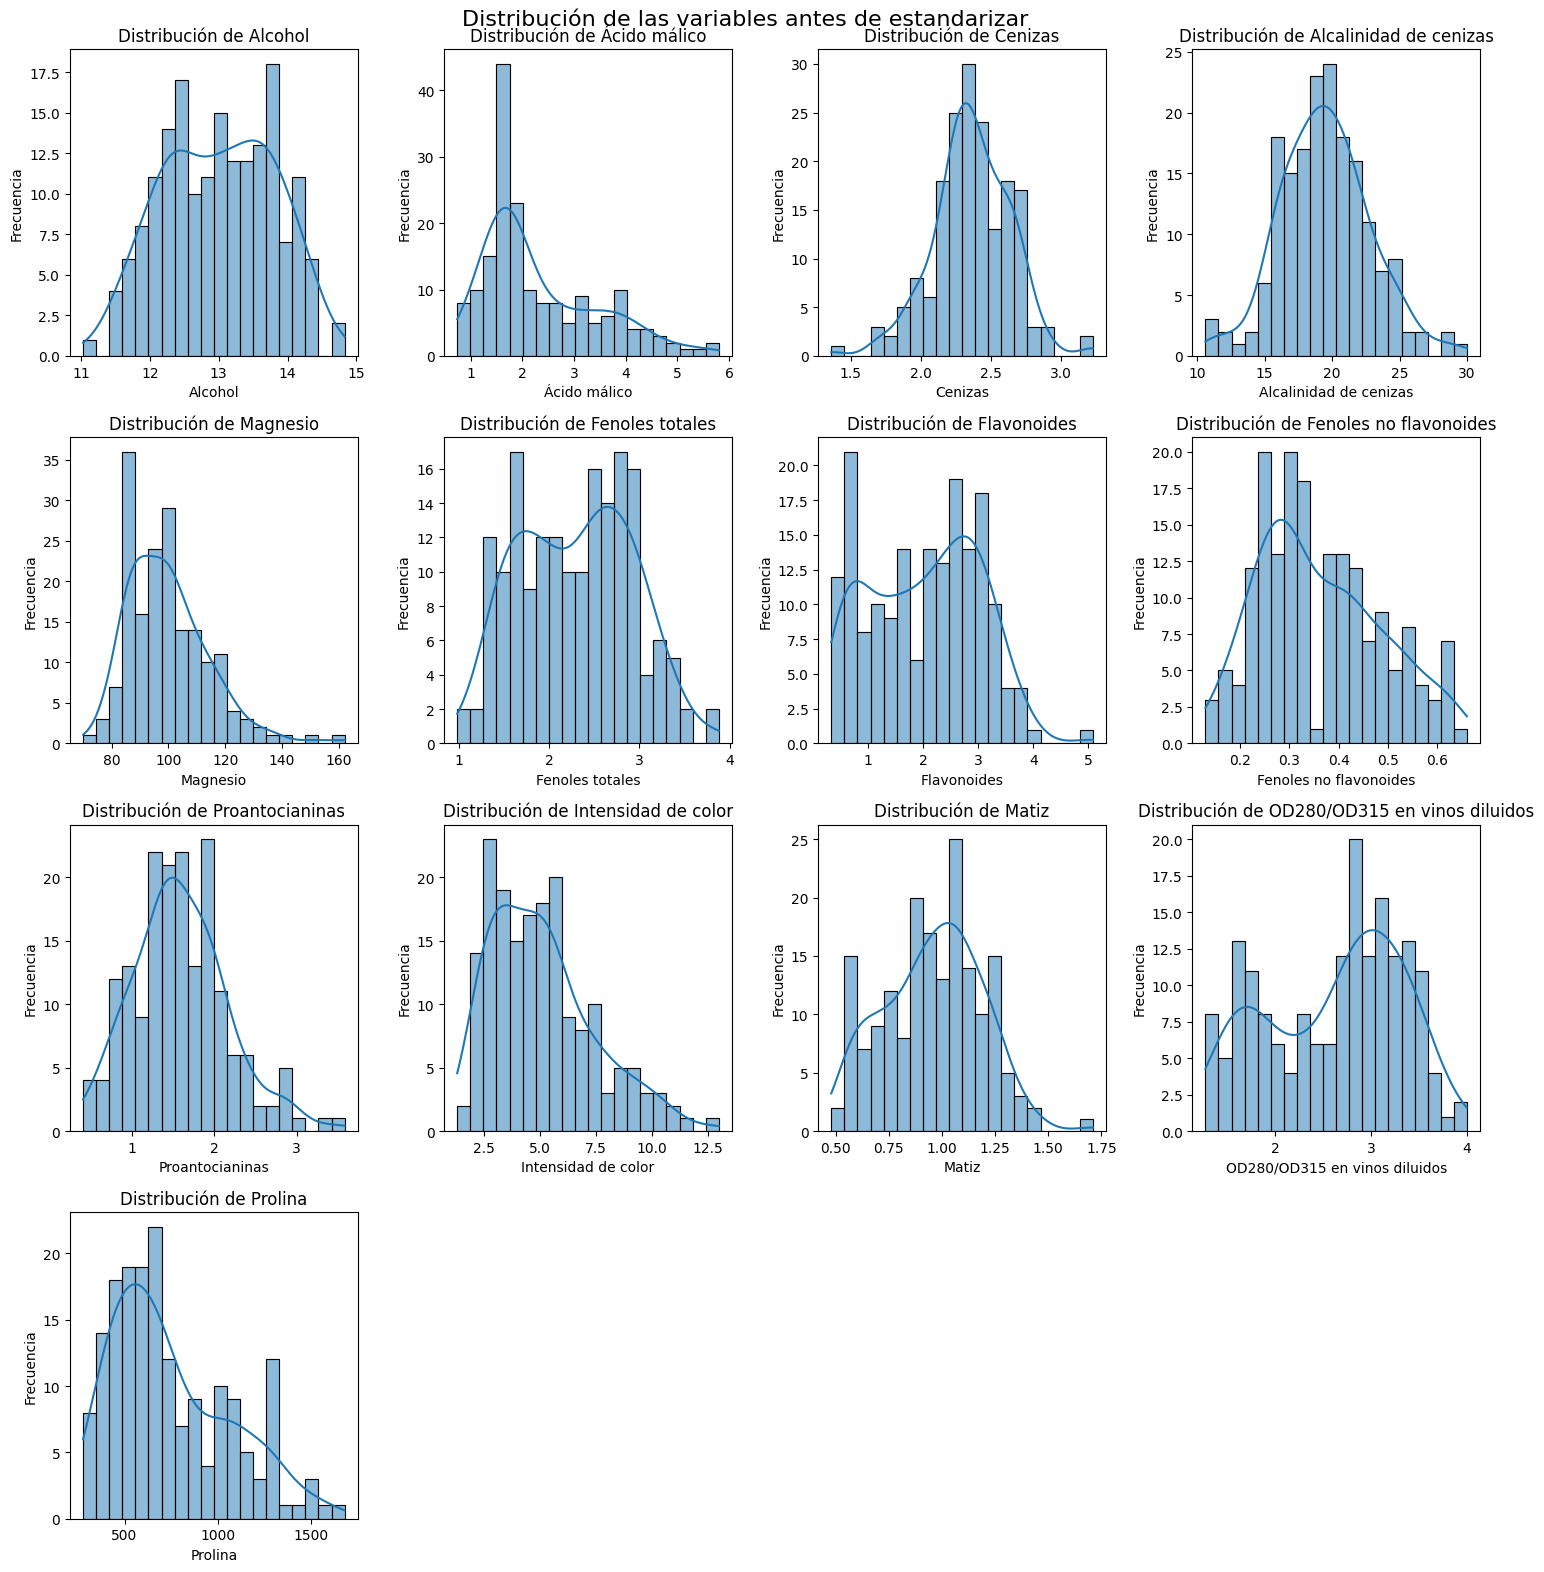

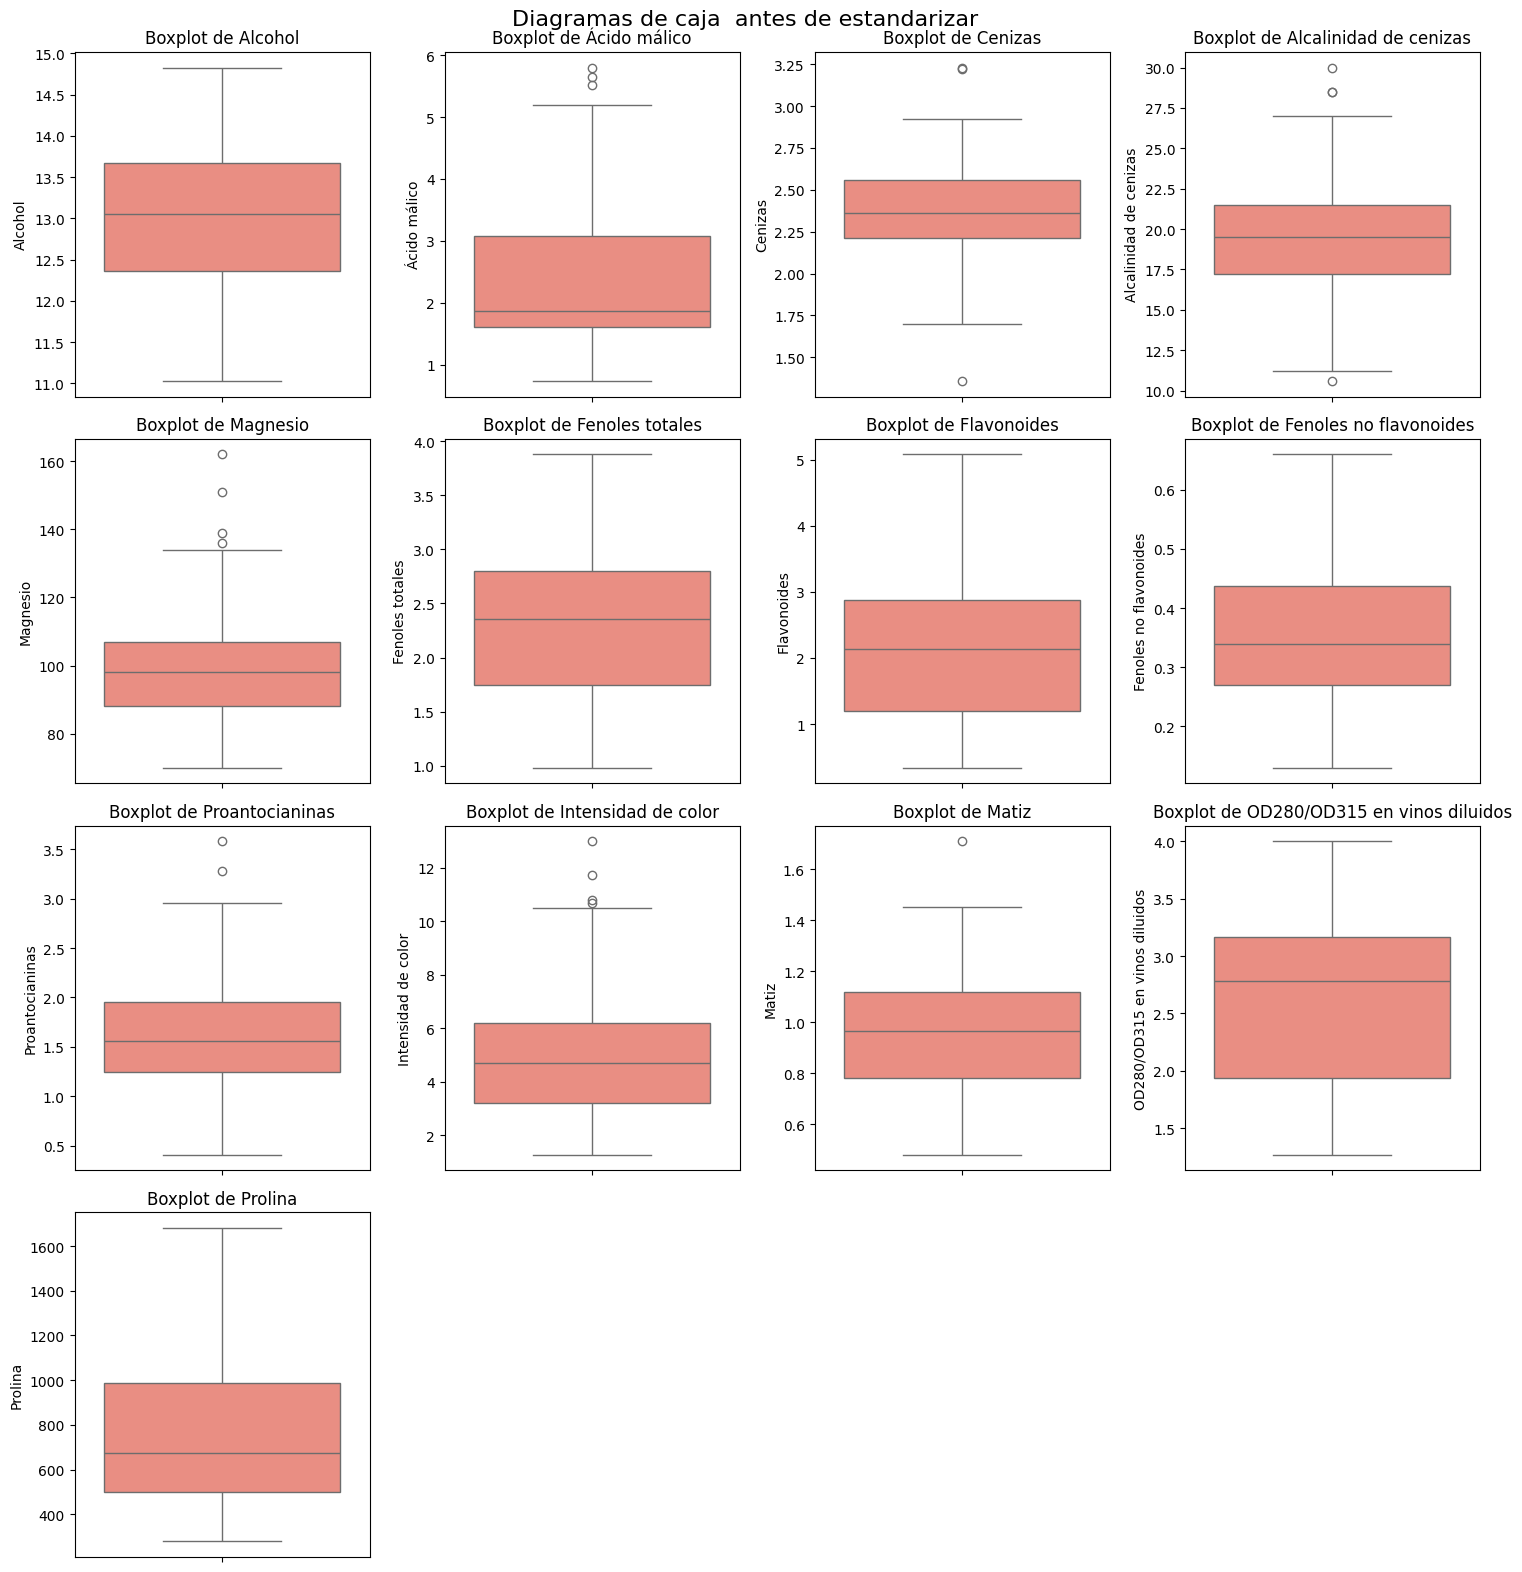

In [67]:
nombres_es = {
    "alcohol": "Alcohol",
    "malic_acid": "Ácido málico",
    "ash": "Cenizas",
    "alcalinity_of_ash": "Alcalinidad de cenizas",
    "magnesium": "Magnesio",
    "total_phenols": "Fenoles totales",
    "flavanoids": "Flavonoides",
    "nonflavanoid_phenols": "Fenoles no flavonoides",
    "proanthocyanins": "Proantocianinas",
    "color_intensity": "Intensidad de color",
    "hue": "Matiz",
    "od280/od315_of_diluted_wines": "OD280/OD315 en vinos diluidos",
    "proline": "Prolina"
}

graficar_distribuciones(X, feature_columns, nombres_es)
graficar_boxplots(X, feature_columns, nombres_es)

In [68]:
# Estandarizar columnas y colocar a las variables en la misma escala antes de aplicar PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns)

X_scaled_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


## 7. Verificación después del escalado

- las medias deberían estar muy cerca de 0,
- las desviaciones estándar cerca de 1.

In [69]:
scaled_summary = pd.DataFrame({
    "Media": X_scaled_df.mean(),
    "Desviación estándar": X_scaled_df.std(ddof=0)
})

scaled_summary

,Media,Desviación estándar
alcohol,7.943708e-15,1.0
malic_acid,3.592632e-16,1.0
ash,-4.066660e-15,1.0
alcalinity_of_ash,-7.983626e-17,1.0
magnesium,-7.983626e-17,1.0
total_phenols,-3.991813e-17,1.0
flavanoids,9.979533e-16,1.0
nonflavanoid_phenols,-5.588538e-16,1.0
proanthocyanins,-1.656602e-15,1.0
color_intensity,-3.442939e-16,1.0


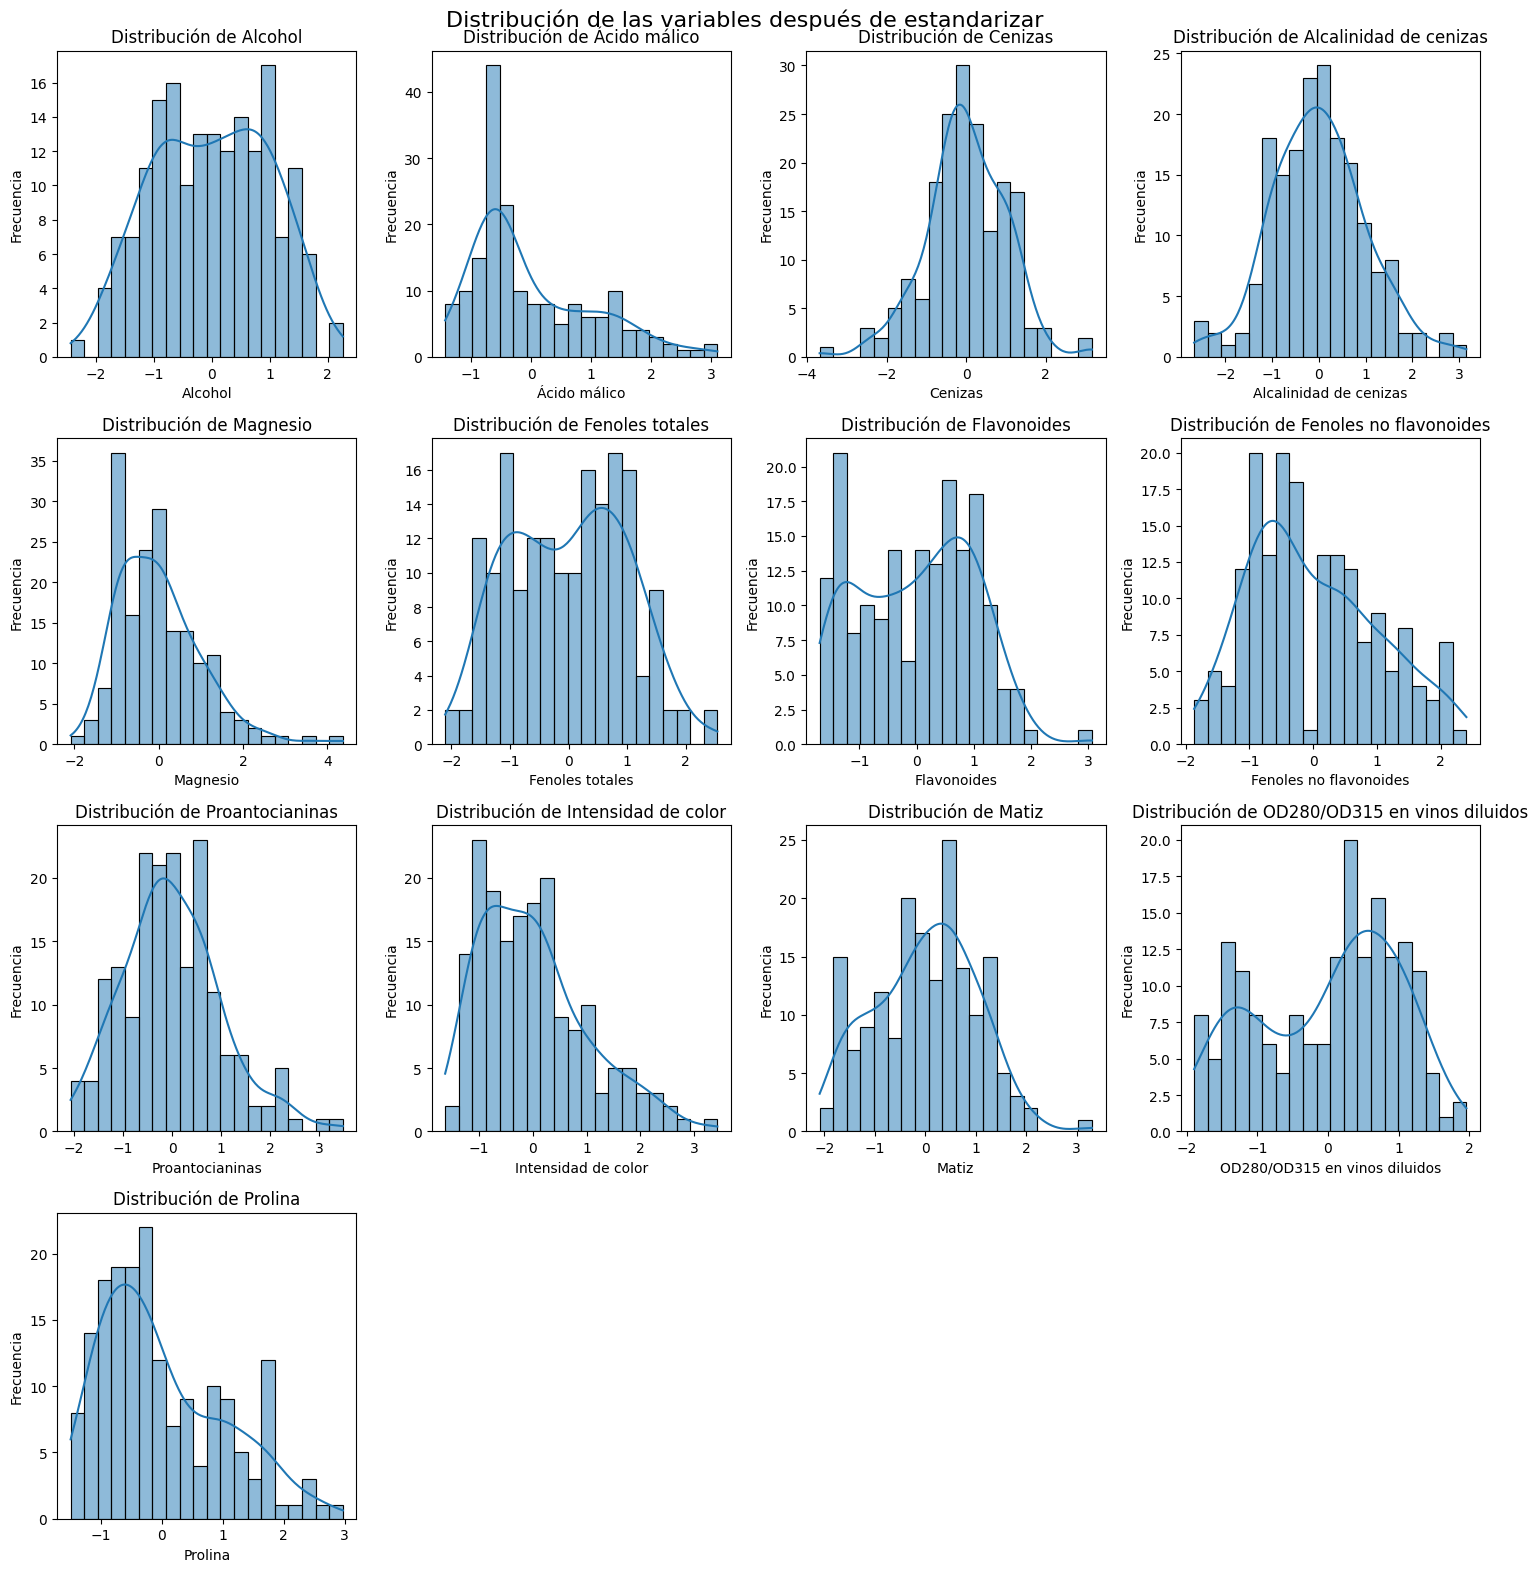

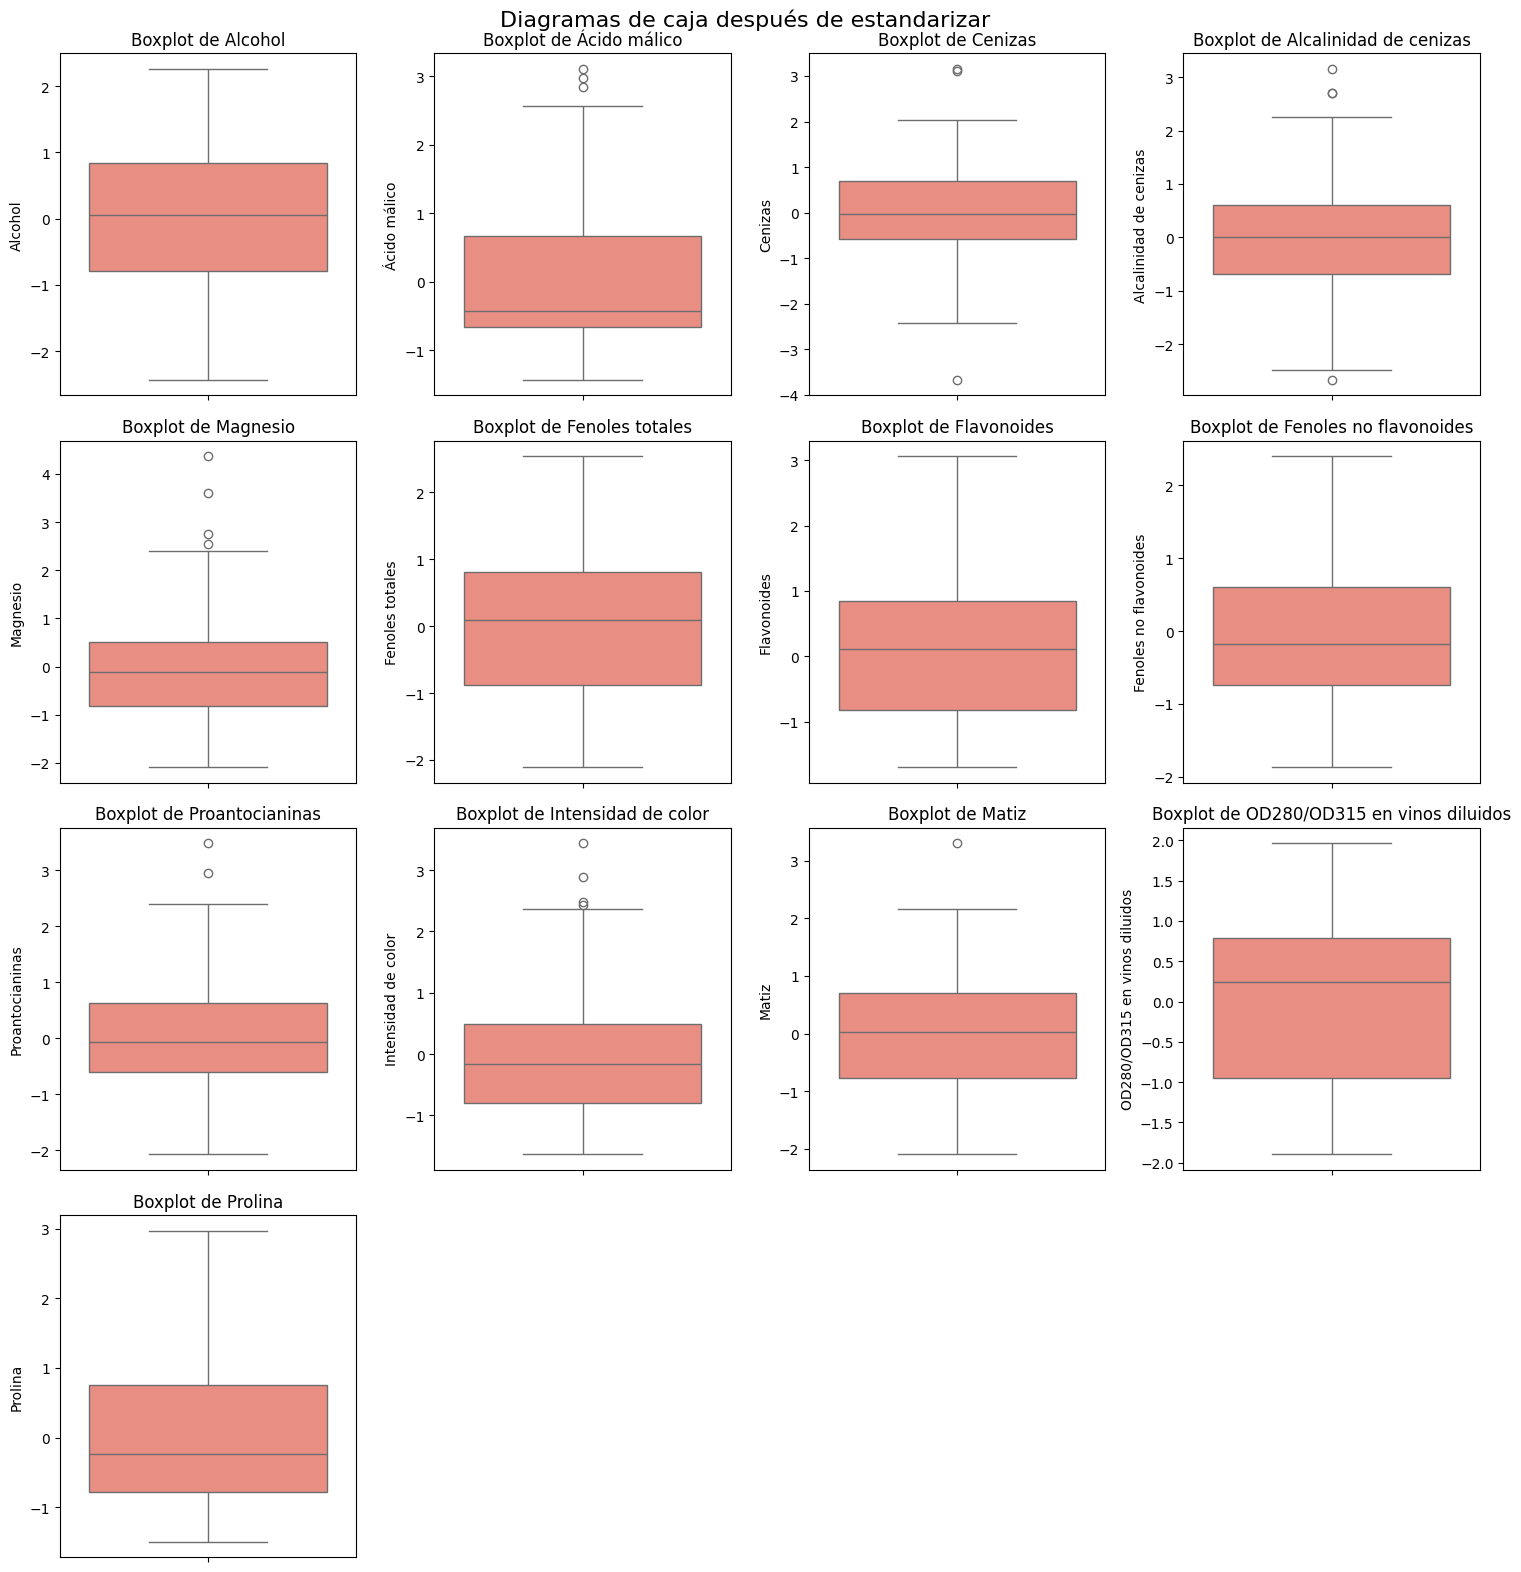

In [70]:
graficar_distribuciones(
    df=X_scaled_df,
    columnas=feature_columns,
    nombres_es=nombres_es,
    titulo="Distribución de las variables después de estandarizar"
)
graficar_boxplots(
    df=X_scaled_df,
    columnas=feature_columns,
    nombres_es=nombres_es,
    titulo="Diagramas de caja después de estandarizar"
)

## 8. Aplicar PCA con todas las componentes

Primero ajustamos PCA con todas las componentes posibles para ver cuánta varianza explica cada una.

In [71]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

variance_table = pd.DataFrame({
    "Componente principal": [f"PC{i+1}" for i in range(len(explained_variance_ratio))],
    "Explained Variance Ratio": explained_variance_ratio,
    "Cumulative Variance Ratio": cumulative_variance_ratio
})

variance_table

,Componente principal,Explained Variance Ratio,Cumulative Variance Ratio
0,PC1,0.361988,0.361988
1,PC2,0.192075,0.554063
2,PC3,0.111236,0.665300
3,PC4,0.070690,0.735990
4,PC5,0.065633,0.801623
5,PC6,0.049358,0.850981
6,PC7,0.042387,0.893368
7,PC8,0.026807,0.920175
8,PC9,0.022222,0.942397
9,PC10,0.019300,0.961697


## 9. Gráfica de varianza explicada

Esta gráfica permite responder preguntas como:
- ¿cuánta información conserva cada componente?
- ¿cuántas componentes conviene conservar?

In [72]:
def graficar_varianza_explicada(
    explained_variance_ratio,
    titulo="Varianza explicada por los componentes principales"
):
    cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
    componentes = range(1, len(explained_variance_ratio) + 1)

    plt.figure(figsize=(10, 6))
    
    plt.bar(
        componentes,
        explained_variance_ratio,
        alpha=0.8,
        label="Varianza explicada individual"
    )
    
    plt.plot(
        componentes,
        cumulative_variance_ratio,
        marker="o",
        label="Varianza explicada acumulada"
    )

    plt.xlabel("Componente principal")
    plt.ylabel("Proporción de varianza explicada")
    plt.title(titulo)
    plt.xticks(componentes)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

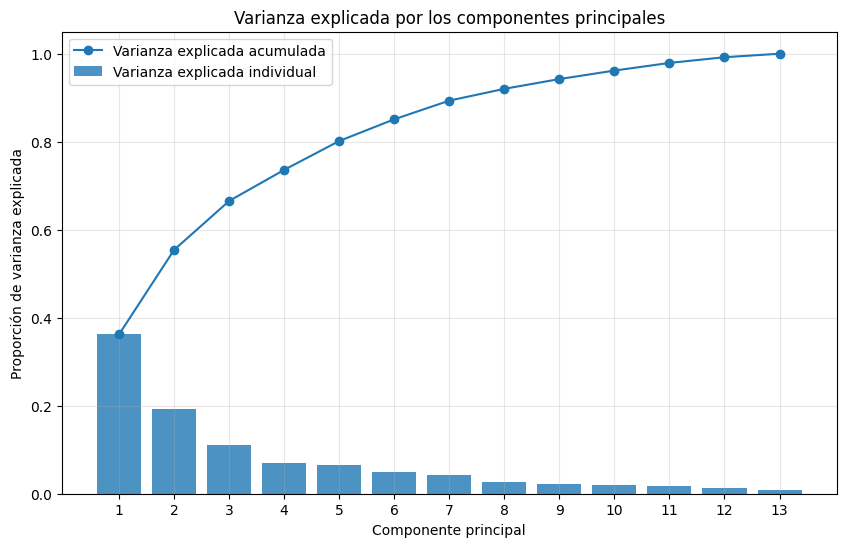

In [73]:
graficar_varianza_explicada(explained_variance_ratio)

## 10. Interpretación de la varianza explicada

Se imprime el porcentaje explicado por cada componente y el acumulado.

In [74]:
for i, (var_ratio, cum_ratio) in enumerate(zip(explained_variance_ratio, cumulative_variance_ratio), start=1):
    print(f"PC{i}: {var_ratio:.4f} ({var_ratio*100:.2f}%) | Cumulative: {cum_ratio:.4f} ({cum_ratio*100:.2f}%)")

PC1: 0.3620 (36.20%) | Cumulative: 0.3620 (36.20%)
PC2: 0.1921 (19.21%) | Cumulative: 0.5541 (55.41%)
PC3: 0.1112 (11.12%) | Cumulative: 0.6653 (66.53%)
PC4: 0.0707 (7.07%) | Cumulative: 0.7360 (73.60%)
PC5: 0.0656 (6.56%) | Cumulative: 0.8016 (80.16%)
PC6: 0.0494 (4.94%) | Cumulative: 0.8510 (85.10%)
PC7: 0.0424 (4.24%) | Cumulative: 0.8934 (89.34%)
PC8: 0.0268 (2.68%) | Cumulative: 0.9202 (92.02%)
PC9: 0.0222 (2.22%) | Cumulative: 0.9424 (94.24%)
PC10: 0.0193 (1.93%) | Cumulative: 0.9617 (96.17%)
PC11: 0.0174 (1.74%) | Cumulative: 0.9791 (97.91%)
PC12: 0.0130 (1.30%) | Cumulative: 0.9920 (99.20%)
PC13: 0.0080 (0.80%) | Cumulative: 1.0000 (100.00%)


## 11. PCA con 2 componentes principales

Ahora reducimos el dataset a dos dimensiones para poder visualizarlo fácilmente.

In [89]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])
pca_df["target"] = y


pca_df.head(0)

,PC1,PC2,target


## 12. Varianza explicada por las dos primeras componentes

In [76]:
pc1_var = pca_2.explained_variance_ratio_[0]
pc2_var = pca_2.explained_variance_ratio_[1]
total_2pc_var = pca_2.explained_variance_ratio_.sum()
print(f"PC1 explica: {explained_variance_ratio[0]:.4f} ({explained_variance_ratio[0]*100:.2f}%)")
print(f"PC2 explica: {explained_variance_ratio[1]:.4f} ({explained_variance_ratio[1]*100:.2f}%)")
print(f"PC1 + PC2 explican: {cumulative_variance_ratio[1]:.4f} ({cumulative_variance_ratio[1]*100:.2f}%)")

PC1 explica: 0.3620 (36.20%)
PC2 explica: 0.1921 (19.21%)
PC1 + PC2 explican: 0.5541 (55.41%)


## 13. Visualización en 2D de las observaciones

Cada punto representa una observación del dataset.  

In [77]:

def graficar_proyeccion_pca(pca_df, pc1_var, pc2_var):
    plt.figure(figsize=(10, 7))

    for clase in sorted(pca_df["target"].unique()):
        subconjunto = pca_df[pca_df["target"] == clase]
        plt.scatter(
            subconjunto["PC1"],
            subconjunto["PC2"],
            label=clase,
            alpha=0.8
        )

    plt.xlabel(f"PC1 ({pc1_var*100:.2f}% de varianza explicada)")
    plt.ylabel(f"PC2 ({pc2_var*100:.2f}% de varianza explicada)")
    plt.title("Proyección PCA del conjunto de datos de vinos")
    plt.legend(title="Clase de vino")
    plt.grid(alpha=0.3)
    plt.show()

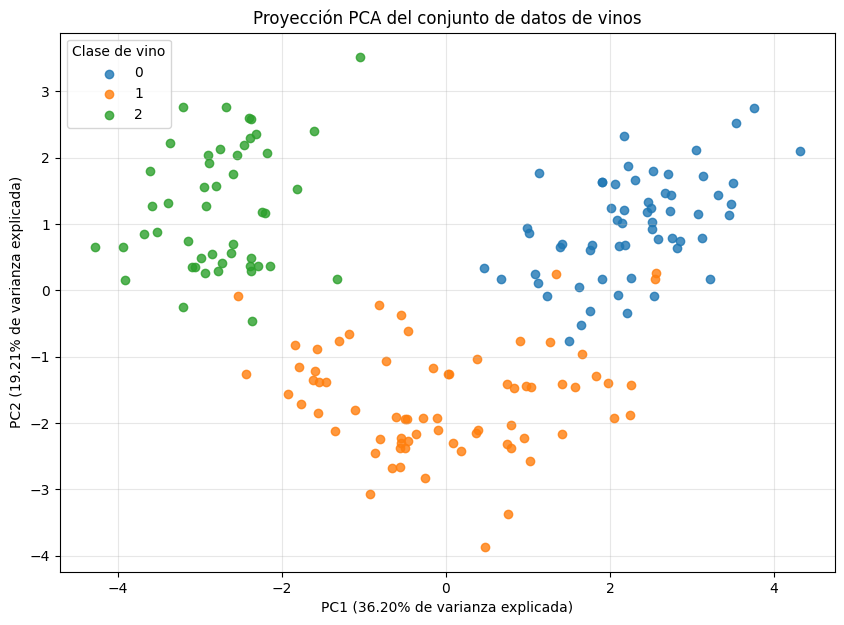

In [78]:
graficar_proyeccion_pca(pca_df, pc1_var, pc2_var)

La proyección de las observaciones sobre las dos primeras componentes principales muestra una separación clara entre las tres clases de vino. El primer componente principal explica el 36.20% de la varianza total y el segundo el 19.21%, acumulando conjuntamente el 55.41%. Esto indica que una parte importante de la estructura de los datos puede visualizarse en dos dimensiones. Finalmente esto permite distinguir adecuadamente los diferentes tipos de vino

## 14. Cargas factoriales

Las **cargas** muestran cuánto contribuye cada variable original a cada componente principal.

En términos prácticos:
- valores altos en magnitud indican mayor influencia,
- el signo indica dirección,
- ayudan a interpretar el significado de cada componente.

In [79]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=["PC1", "PC2"],
    index=feature_columns
)

loadings

,PC1,PC2
alcohol,0.144329,0.483652
malic_acid,-0.245188,0.224931
ash,-0.002051,0.316069
alcalinity_of_ash,-0.239320,-0.010591
magnesium,0.141992,0.299634
total_phenols,0.394661,0.065040
flavanoids,0.422934,-0.003360
nonflavanoid_phenols,-0.298533,0.028779
proanthocyanins,0.313429,0.039302
color_intensity,-0.088617,0.529996


## 15. Variables más influyentes en PC1 y PC2

In [80]:
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False)
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False)

print("Variables principales que más contribuyen a la CP1:")
print(top_pc1)

print("\nVariables principales que más contribuyen a la CP2:")
print(top_pc2)

Variables principales que más contribuyen a la CP1:
flavanoids                      0.422934
total_phenols                   0.394661
od280/od315_of_diluted_wines    0.376167
proanthocyanins                 0.313429
nonflavanoid_phenols            0.298533
hue                             0.296715
proline                         0.286752
malic_acid                      0.245188
alcalinity_of_ash               0.239320
alcohol                         0.144329
magnesium                       0.141992
color_intensity                 0.088617
ash                             0.002051
Name: PC1, dtype: float64

Variables principales que más contribuyen a la CP2:
color_intensity                 0.529996
alcohol                         0.483652
proline                         0.364903
ash                             0.316069
magnesium                       0.299634
hue                             0.279235
malic_acid                      0.224931
od280/od315_of_diluted_wines    0.164496
total_ph

## 16. Visualización de las cargas de PC1

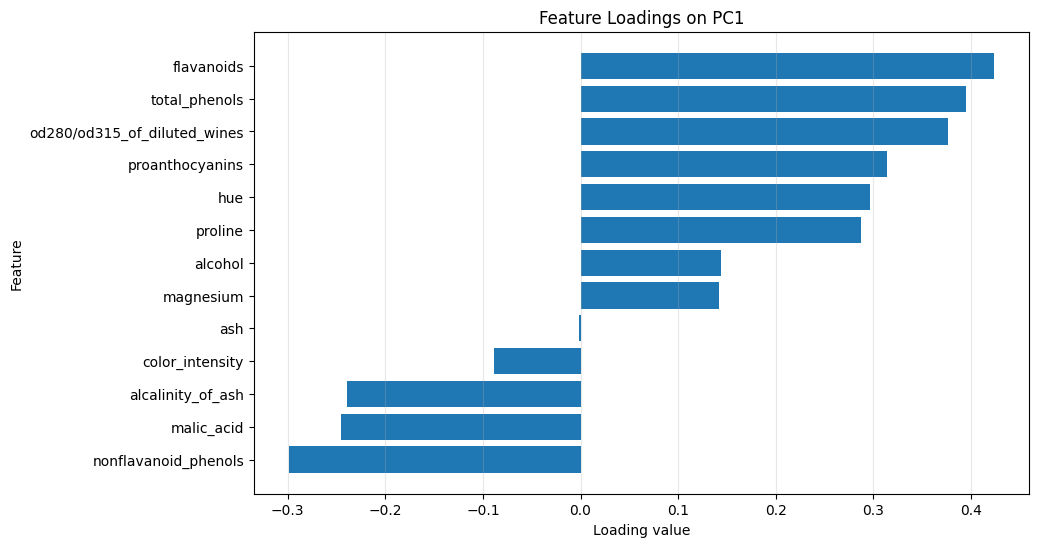

In [81]:
pc1_sorted = loadings["PC1"].sort_values()

plt.figure(figsize=(10, 6))
plt.barh(pc1_sorted.index, pc1_sorted.values)
plt.xlabel("Valor de la carga")
plt.ylabel("Variable")
plt.title("Cargas de las variables en PC1")
plt.grid(axis="x", alpha=0.3)
plt.show()

## 17. Visualización de las cargas de PC2

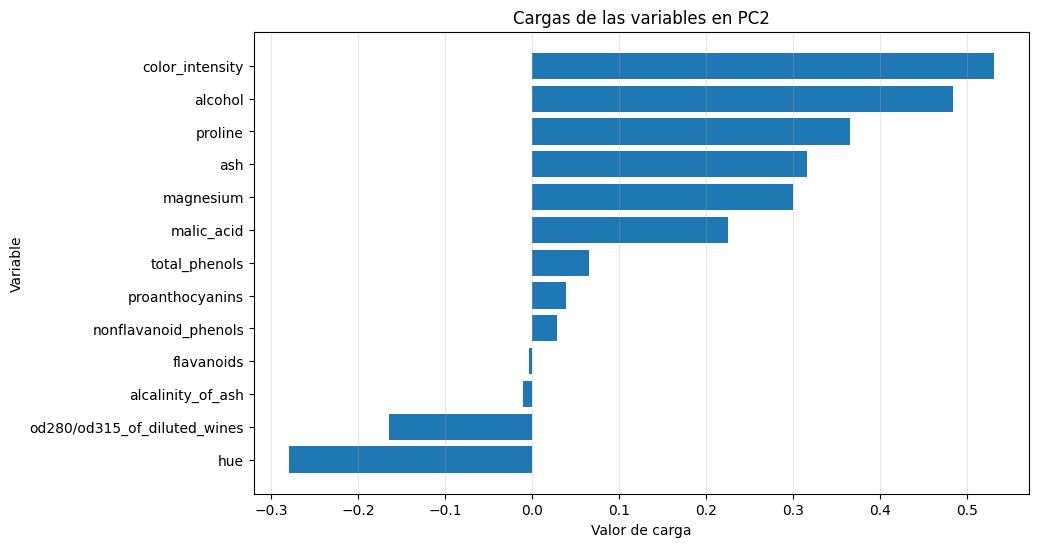

In [82]:
pc2_sorted = loadings["PC2"].sort_values()

plt.figure(figsize=(10, 6))
plt.barh(pc2_sorted.index, pc2_sorted.values)
plt.xlabel("Valor de carga")
plt.ylabel("Variable")
plt.title("Cargas de las variables en PC2")
plt.grid(axis="x", alpha=0.3)
plt.show()

## 18. Conclusiones

A partir del análisis podemos resumir que:

1. **PCA reduce la dimensionalidad** del dataset sin perder toda la información.
2. Las primeras componentes suelen capturar una parte importante de la variabilidad total.
3. La visualización en dos dimensiones facilita observar posibles patrones o separación entre clases.
4. Las cargas permiten interpretar qué variables originales influyen más en cada componente
5. PCA transforma variables originales correlacionadas en nuevas variables:
6.  no correlacionadas entre sí,
7.  ordenadas por cantidad de varianza explicada.

## 19. Ejercicio

Intenta responder:
1. ¿Cuánto porcentaje de la varianza total explican las dos primeras componentes?
2. ¿Qué variables tienen mayor peso en PC1?
3. ¿Se observan grupos separados entre las clases de vino?
4. ¿Qué ocurre si usas 3 componentes en lugar de 2?
4. ¿Qué ocurre si usas 5 componentes Justifica tu respuesta


In [85]:
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

print("Proporción de varianza explicada para 3 componentes:")
print(pca_3.explained_variance_ratio_)
print("Varianza explicada acumulada:")
print(np.cumsum(pca_3.explained_variance_ratio_))

Proporción de varianza explicada para 3 componentes:
[0.36198848 0.1920749  0.11123631]
Varianza explicada acumulada:
[0.36198848 0.55406338 0.66529969]
